In [1]:
%reload_ext autoreload
%autoreload 2

# Forecasting Module Demo
Пример использования Forecaster c dummy-моделями.

In [2]:
import sys
sys.path.append("..")

In [4]:
# scripts/train_stat_all.py
import pandas as pd
from src.stat_models import ARIMAXForecaster

df = pd.read_csv(r"C:\Users\makanov.artem\Desktop\ВР\imto_ts\data\df.csv", index_col=0)
holiday_cols = [ "event_name_1", "event_type_1", "event_name_2", "event_type_2"]
exog_cols = ["wday", "month", "year","CASHBACK_STORE_1", "sell_price"] + holiday_cols
df[holiday_cols] = (~df[holiday_cols].isna()).astype(int)
df.head()

,item_id,store_id,date_id,cnt,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,CASHBACK_STORE_1,CASHBACK_STORE_2,CASHBACK_STORE_3,sell_price
0,STORE_1_046,STORE_1,1033,4,2013-11-26,11344,Tuesday,4,11,2013,0,0,0,0,0,0,0,0.98
1,STORE_1_046,STORE_1,1034,1,2013-11-27,11344,Wednesday,5,11,2013,0,0,0,0,0,0,0,0.98
2,STORE_1_046,STORE_1,1035,0,2013-11-28,11344,Thursday,6,11,2013,1,1,0,0,0,0,0,0.98
3,STORE_1_046,STORE_1,1036,4,2013-11-29,11344,Friday,7,11,2013,0,0,0,0,0,0,0,0.98
4,STORE_1_046,STORE_1,1037,1,2013-11-30,11345,Saturday,1,11,2013,0,0,0,0,0,0,0,0.98


In [5]:
item = 'STORE_1_046'
df_item = df[df.item_id == item]


In [ ]:
item = 'STORE_1_046'
df_item = df[df.item_id == item]

forecaster = ARIMAXForecaster(order=(7,1,7), seasonal_order=(1,1,1,24), exog_cols=exog_cols)

forecaster.train(df_item, item)

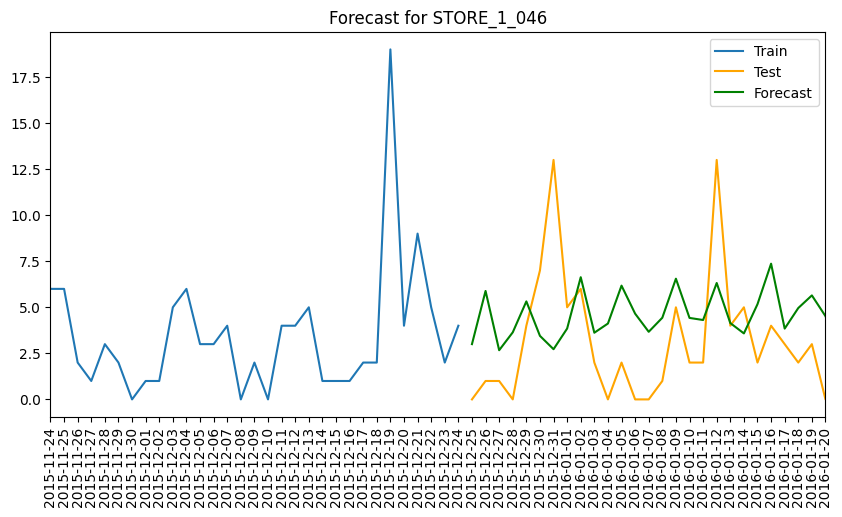

{'MAPE': np.float64(842994684.9172719),
 'RMSE': np.float64(3.664021874780804),
 'MAE': np.float64(3.053876393159466),
 'SMAPE': np.float64(0.9546715134163114),
 'WAPE': np.float64(0.97168794326697),
 'MASE': np.float64(1.1691102555630684)}

In [7]:
forecaster.evaluate(df_item, item)